<a href="https://colab.research.google.com/github/jkeerthiga/codtech-internship/blob/main/Sales_Trend_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('Fashion_Retail_Sales.csv')

print("Shape:", df.shape)
df.head()

Shape: (3400, 6)


,Customer Reference ID,Item Purchased,Purchase Amount (USD),Date Purchase,Review Rating,Payment Method
0,4018,Handbag,4619.0,05-02-2023,NaN,Credit Card
1,4115,Tunic,2456.0,11-07-2023,2.0,Credit Card
2,4019,Tank Top,2102.0,23-03-2023,4.1,Cash
3,4097,Leggings,3126.0,15-03-2023,3.2,Cash
4,3997,Wallet,3003.0,27-11-2022,4.7,Cash


In [ ]:
df.dtypes

,0
Customer Reference ID,int64
Item Purchased,object
Purchase Amount (USD),float64
Date Purchase,object
Review Rating,float64
Payment Method,object


In [ ]:
df.isnull().sum()

,0
Customer Reference ID,0
Item Purchased,0
Purchase Amount (USD),650
Date Purchase,0
Review Rating,324
Payment Method,0


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [ ]:
df['Date Purchase'] = pd.to_datetime(df['Date Purchase'], format='%d-%m-%Y')

df['Purchase Amount (USD)'] = df.groupby('Item Purchased')['Purchase Amount (USD)'] \
    .transform(lambda x: x.fillna(x.median()))

df['Purchase Amount (USD)'] = df['Purchase Amount (USD)'].fillna(df['Purchase Amount (USD)'].median())

df = df.drop_duplicates()

print("Remaining nulls in Purchase Amount:", df['Purchase Amount (USD)'].isnull().sum())
print("Final shape:", df.shape)
print("Purchase Amount dtype:", df['Purchase Amount (USD)'].dtype)

Remaining nulls in Purchase Amount: 0
Final shape: (3400, 6)
Purchase Amount dtype: float64


In [ ]:
total_revenue = df['Purchase Amount (USD)'].sum()
avg_purchase = df['Purchase Amount (USD)'].mean()
unique_customers = df['Customer Reference ID'].nunique()
unique_products = df['Item Purchased'].nunique()
avg_rating = df['Review Rating'].mean()

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Average Purchase Amount: ${avg_purchase:,.2f}")
print(f"Number of Unique Customers: {unique_customers}")
print(f"Number of Unique Products: {unique_products}")
print(f"Average Review Rating: {avg_rating:.2f} / 5")

Total Revenue: $501,897.00
Average Purchase Amount: $147.62
Number of Unique Customers: 166
Number of Unique Products: 50
Average Review Rating: 3.00 / 5


In [ ]:
import os
os.makedirs('charts',exist_ok=True)

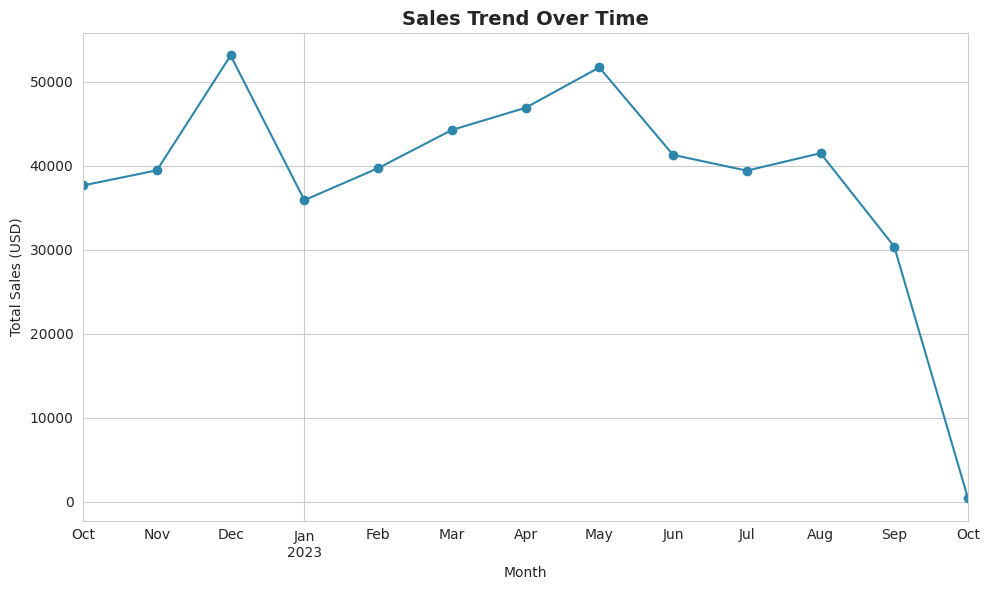

In [ ]:
df['Month'] = df['Date Purchase'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Purchase Amount (USD)'].sum()

plt.figure()
monthly_sales.plot(kind='line', marker='o', color='#2E86AB')
plt.title('Sales Trend Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Sales (USD)')
plt.tight_layout()
plt.savefig('charts/sales_trend.png', dpi=150)
plt.show()

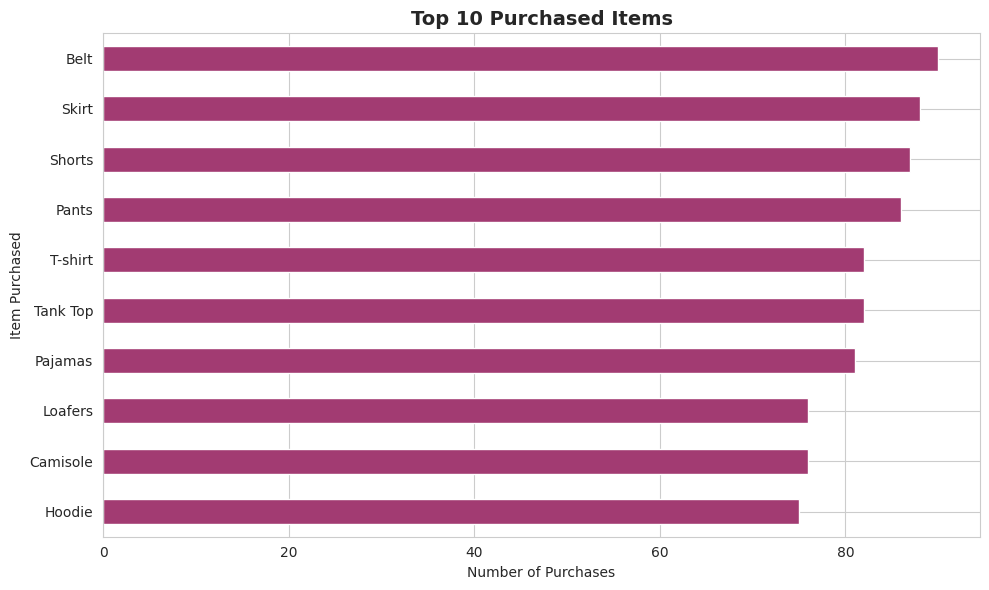

In [ ]:
top_items = df['Item Purchased'].value_counts().head(10)

plt.figure()
top_items.plot(kind='barh', color='#A23B72')
plt.title('Top 10 Purchased Items', fontsize=14, fontweight='bold')
plt.xlabel('Number of Purchases')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('charts/top_items.png', dpi=150)
plt.show()

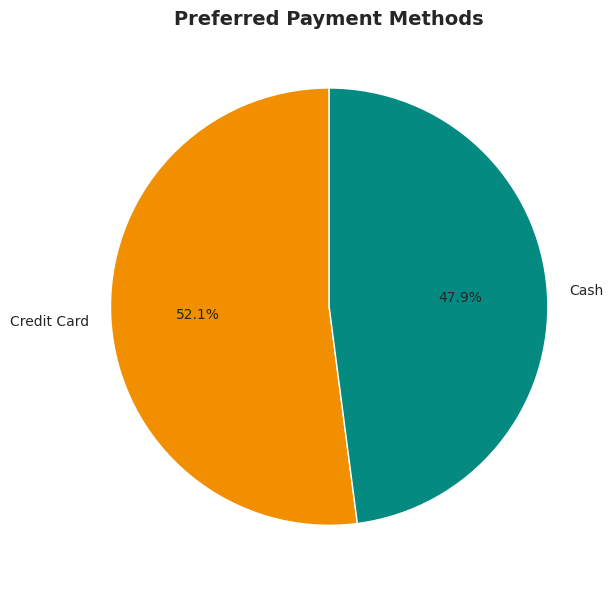

In [ ]:
payment_counts = df['Payment Method'].value_counts()

plt.figure()
plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%',
        colors=['#F18F01', '#048A81'], startangle=90)
plt.title('Preferred Payment Methods', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/payment_methods.png', dpi=150)
plt.show()

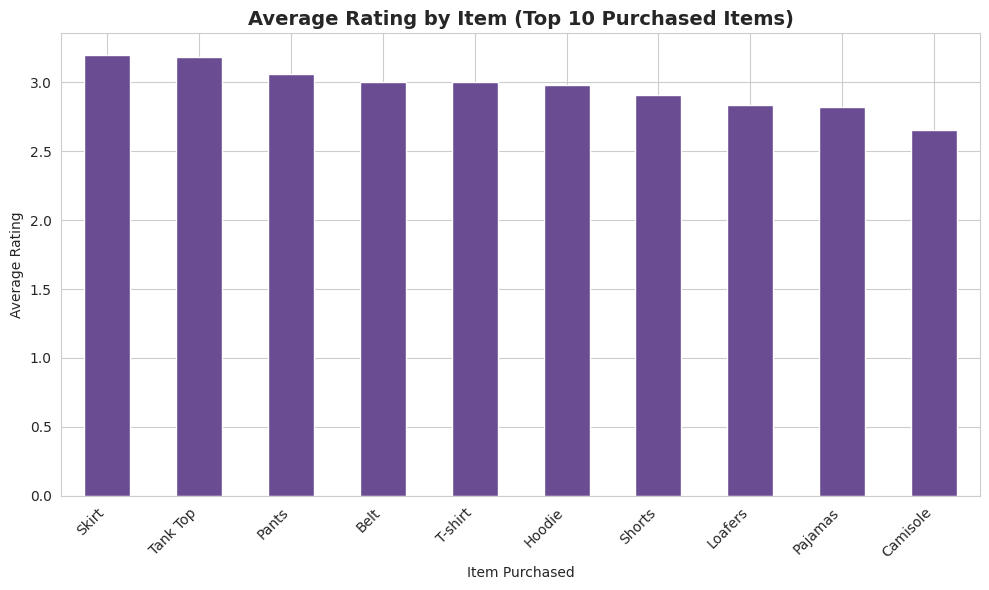

In [ ]:
top10_names = top_items.index
avg_rating_by_item = df[df['Item Purchased'].isin(top10_names)] \
    .groupby('Item Purchased')['Review Rating'].mean().sort_values(ascending=False)

plt.figure()
avg_rating_by_item.plot(kind='bar', color='#6A4C93')
plt.title('Average Rating by Item (Top 10 Purchased Items)', fontsize=14, fontweight='bold')
plt.ylabel('Average Rating')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('charts/avg_rating.png', dpi=150)
plt.show()

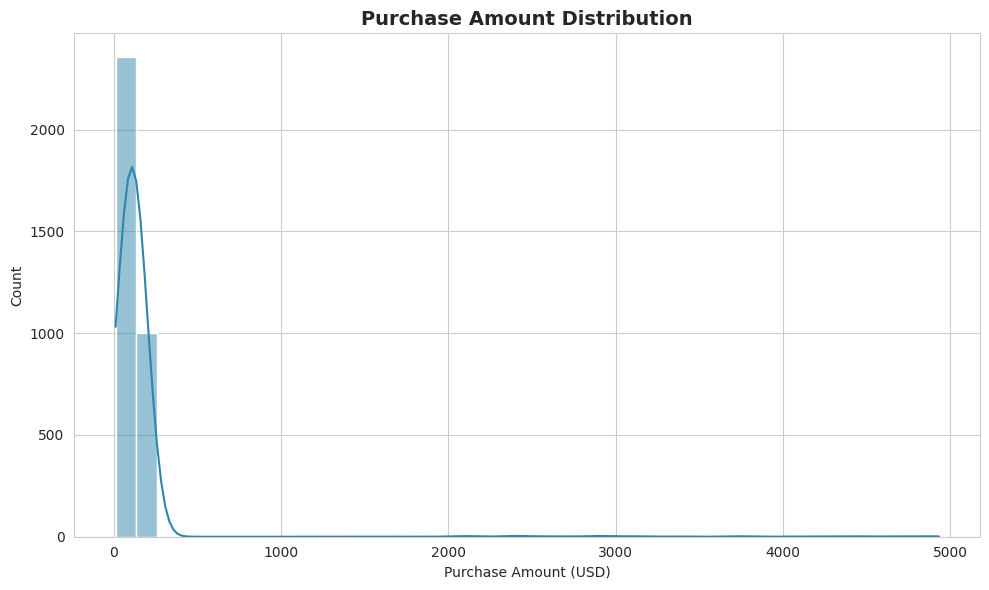

In [ ]:
plt.figure()
sns.histplot(df['Purchase Amount (USD)'], bins=40, color='#2E86AB', kde=True)
plt.title('Purchase Amount Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Purchase Amount (USD)')
plt.tight_layout()
plt.savefig('charts/purchase_distribution.png', dpi=150)
plt.show()

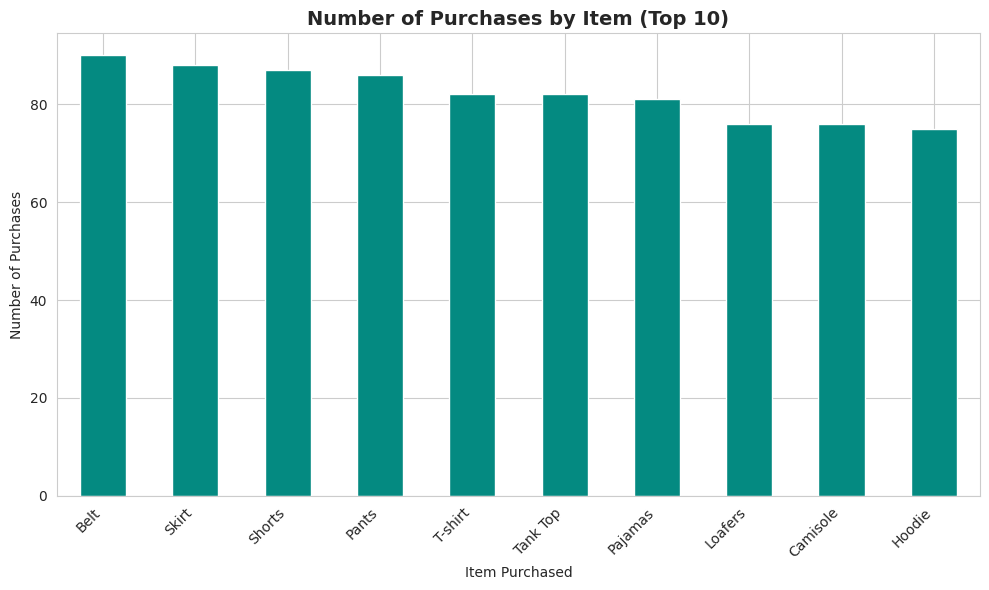

In [ ]:
plt.figure()
top_items.plot(kind='bar', color='#048A81')
plt.title('Number of Purchases by Item (Top 10)', fontsize=14, fontweight='bold')
plt.ylabel('Number of Purchases')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('charts/purchases_by_item.png', dpi=150)
plt.show()

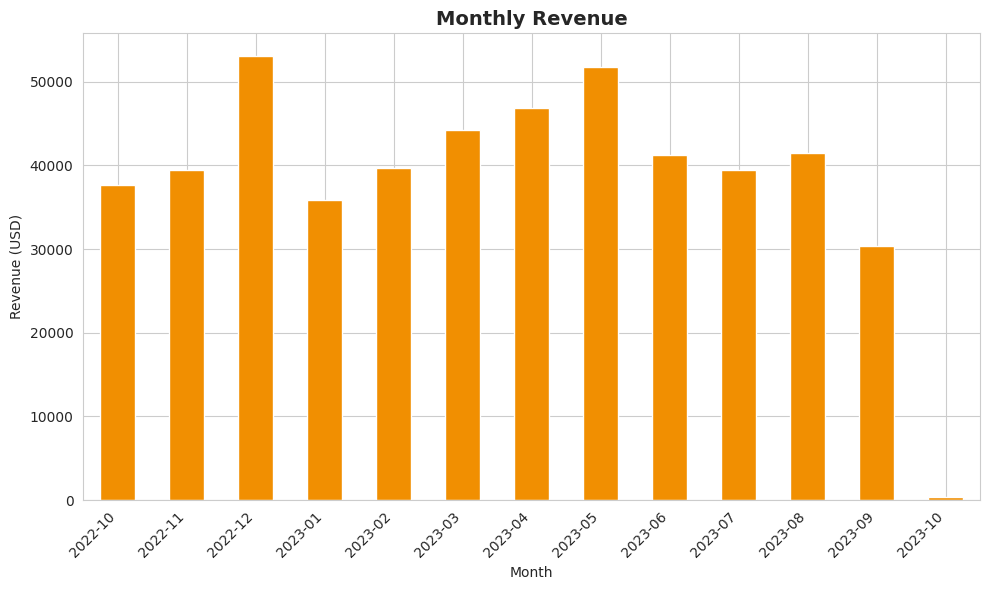

In [ ]:
plt.figure()
monthly_sales.plot(kind='bar', color='#F18F01')
plt.title('Monthly Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue (USD)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('charts/monthly_revenue.png', dpi=150)
plt.show()

In [ ]:
revenue_by_item = df.groupby('Item Purchased')['Purchase Amount (USD)'].sum().sort_values(ascending=False)
print("Top 5 items by total revenue:")
print(revenue_by_item.head(), "\n")

print("Payment method split:")
print(payment_counts, "\n")

best_month = monthly_sales.idxmax()
worst_month = monthly_sales.idxmin()
print(f"Strongest month: {best_month} (${monthly_sales.max():,.2f})")
print(f"Weakest month: {worst_month} (${monthly_sales.min():,.2f})\n")

item_stats = df.groupby('Item Purchased').agg(
    total_revenue=('Purchase Amount (USD)', 'sum'),
    avg_rating=('Review Rating', 'mean')
)
correlation = item_stats.corr().iloc[0, 1]
print(f"Correlation between item revenue and average rating: {correlation:.3f}")

Top 5 items by total revenue:
Item Purchased
Tunic      18143.0
Pajamas    15178.0
Jeans      14378.0
Shorts     14138.5
Handbag    13890.0
Name: Purchase Amount (USD), dtype: float64 

Payment method split:
Payment Method
Credit Card    1770
Cash           1630
Name: count, dtype: int64 

Strongest month: 2022-12 ($53,139.50)
Weakest month: 2023-10 ($423.00)

Correlation between item revenue and average rating: -0.093


## Interpretation of Insights

- Top revenue drivers: Tunic, Pajamas, Jeans, Shorts, and Handbag lead total revenue — these are the categories worth prioritizing for stock and marketing focus.
- Payment preference: Credit Card is used slightly more often than Cash (52.1% vs 47.9%), suggesting no urgent need to change payment infrastructure, but a mild lean toward digital payment support.
- Seasonality: December shows the strongest sales, consistent with holiday-season shopping behavior. Note: October 2023 appears as the weakest month, but this is a data artifact — the dataset only contains 1 day of October 2023, so that month is incomplete and shouldn't be read as a real trend.
- Rating vs. revenue: The correlation between an item's average rating and total revenue is essentially zero (-0.093). Popularity isn't driven by satisfaction scores — customers buy based on other factors like price or necessity, not reviews.

## Recommendations

1. Prioritize inventory and marketing spend on the top 5 revenue-driving items ahead of peak season.
2. Prepare for a December sales surge — increase stock and staffing in the weeks leading up to it.
3. Investigate low-rating, high-volume items — since rating doesn't predict revenue, some popular items may be quietly accumulating dissatisfaction worth a quality review.
4. Payment method infrastructure is fine as-is — the near-even split doesn't justify deprecating either option.

## Conclusion

This analysis turned a raw transaction log into a clear business narrative: fashion sales peak around the December holiday season, are concentrated in a handful of high-revenue categories, and are not meaningfully influenced by customer satisfaction scores. These findings translate directly into inventory, marketing, and quality-review recommendations — demonstrating the full analytics workflow from messy raw data to actionable business insight.